<a href="https://colab.research.google.com/github/mafelh111/Parcial-Economia2/blob/main/ED_2024_II_Proyecto_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Triki
Escriba un programa que pueda jugar triki de manera efectiva.

Para ello necesitarás crear un árbol de juego T. T es un árbol donde cada nodo corresponde a una configuración de juego, que en este caso es una representación del tablero de triki.

El nodo raíz corresponde a la configuración inicial.
Para cada nodo interno v en T, los hijos de v corresponden a los estados del juego que podemos alcanzar desde el estado del juego de v en un solo movimiento legal para el jugador apropiado, A (el primer jugador) o B (el segundo jugador).

Los nodos a profundidades pares corresponden a movimientos de A y los nodos a profundidades impares corresponden a movimientos de B. Los nodos externos son estados finales del juego.

Anotamos cada nodo externo con un valor que indica qué tan bueno es este estado para el jugador A. En juegos grandes, como el ajedrez, tenemos que usar una función de puntuación heurística, pero para juegos pequeños, como triki, podemos construir todo el árbol del juego y puntúa los nodos externos como +1, 0, -1, lo que indica si el jugador A gana, empata o pierde en esa configuración.

Un buen algoritmo para elegir movimientos es [minimax](https://es.wikipedia.org/wiki/Minimax). En nuestro algoritmo, asignamos un puntaje a cada nodo interno v en T, de modo que si v representa el turno de A, calculamos el puntaje de v como el máximo de los puntajes de los hijos de v (que corresponde al juego óptimo de A de v). Si un nodo interno v representa el turno de B, entonces calculamos el puntaje de v como el mínimo de los puntajes de los hijos de v (que corresponde al juego óptimo de B de v).

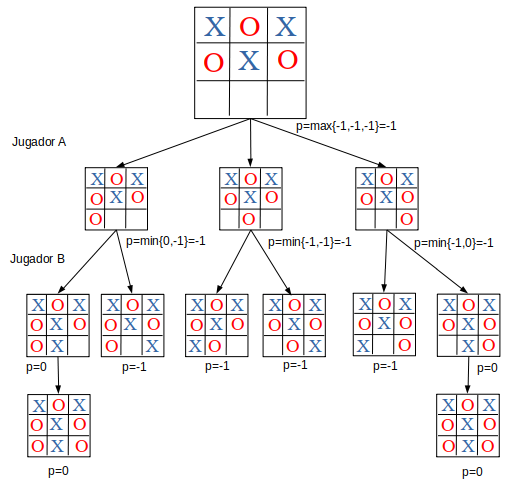

In [1]:
#@title Clase de arboles: LinkedTree
class Tree:
    """Clase base abstracta para representar un árbol."""

    class Position:
        """Abstracción que representa la ubicación de un único elemento."""

        def element(self):
            """Devuelve el elemento almacenado en esta Position."""
            raise NotImplementedError('Debe ser implementado por una subclase')

        def __eq__(self, other):
            """Devuelve True si otra Position representa la misma ubicación."""
            raise NotImplementedError('Debe ser implementado por una subclase')

    def root(self):
        """Devuelve la Position de la raíz del árbol."""
        raise NotImplementedError('Debe ser implementado por una subclase')

    def parent(self, p):
        """Devuelve la Position del padre de p (o None si p es la raíz)."""
        raise NotImplementedError('Debe ser implementado por una subclase')

    def num_children(self, p):
        """Devuelve el número de hijos que tiene la Position p."""
        raise NotImplementedError('Debe ser implementado por una subclase')

    def children(self, p):
        """Genera una iteración de las Positions que representan a los hijos de p."""
        raise NotImplementedError('Debe ser implementado por una subclase')

    def __len__(self):
        """Devuelve el número total de elementos en el árbol."""
        raise NotImplementedError('Debe ser implementado por una subclase')


class LinkedTree(Tree):
    """Implementación concreta de un árbol enlazado utilizando nodos."""

    class _Node:
        """Clase interna para representar un nodo."""
        __slots__ = '_element', '_parent', '_children'

        def __init__(self, element, parent=None):
            self._element = element
            self._parent = parent
            self._children = []

    class Position(Tree.Position):
        """Clase que representa la ubicación de un nodo dentro del árbol."""

        def __init__(self, container, node):
            """Crea una posición que referencia a un nodo específico."""
            self._container = container
            self._node = node

        def element(self):
            """Devuelve el elemento almacenado en el nodo de esta posición."""
            return self._node._element

        def __eq__(self, other):
            """Devuelve True si `other` representa la misma Position."""
            return type(other) is type(self) and other._node is self._node

    def _validate(self, p):
        """Verifica si una posición es válida y devuelve el nodo asociado."""
        if not isinstance(p, self.Position):
            raise TypeError('p debe ser de tipo Position')
        if p._container is not self:
            raise ValueError('p no pertenece a este contenedor')
        if p._node._parent is p._node:  # Nodo retirado
            raise ValueError('p ya no es válido')
        return p._node

    def _make_position(self, node):
        """Crea una instancia de Position para un nodo dado (o None si no existe)."""
        return self.Position(self, node) if node is not None else None

    def __init__(self):
        """Crea un árbol inicialmente vacío."""
        self._root = None
        self._size = 0

    def __len__(self):
        """Devuelve el número total de elementos en el árbol."""
        return self._size

    def root(self):
        """Devuelve la Position que representa la raíz del árbol (o None si está vacío)."""
        return self._make_position(self._root)

    def parent(self, p):
        """Devuelve la Position que representa al padre de p (o None si p es la raíz)."""
        node = self._validate(p)
        return self._make_position(node._parent)

    def num_children(self, p):
        """Devuelve el número de hijos que tiene p."""
        node = self._validate(p)
        return len(node._children)

    def children(self, p):
        """Genera una iteración de las posiciones de los hijos de p."""
        node = self._validate(p)
        for child in node._children:
            yield self._make_position(child)

    def add_root(self, element):
        """Coloca el elemento `element` como la raíz del árbol y devuelve su Position."""
        if self._root is not None:
            raise ValueError('El árbol ya tiene una raíz')
        self._root = self._Node(element)
        self._size = 1
        return self._make_position(self._root)

    def add_child(self, p, element):
        """Añade un hijo con el `element` al nodo representado por `p`."""
        node = self._validate(p)
        child_node = self._Node(element, parent=node)
        node._children.append(child_node)
        self._size += 1
        return self._make_position(child_node)


In [2]:
t = LinkedTree()
t.add_root([["X","O","X"],["O","X","O"],["","",""]])
len(t)

1

In [3]:
def Puntaje(t):
    """Calcula el puntaje de un estado de triki
    >>>t = LinkedTree([["X","O","X"],["O","X","O"],["","",""]])
    >>> Puntaje(t)
    -1
    """

def Siguiente_Movimiento(t):
    """ Calcula uno de los mejores movimientos siguientes
    >>>t = LinkedTree([["X","O","X"],["O","X","O"],["","",""]])
    >>> Siguiente_Movimiento(t)
    LinkedTree([["X","O","X"],["O","X","O"],["O","",""]])
    """